# Bank Credit Card Churn Prediction
## Data Loading & Initial Analysis

The goal of this notebook is to load the dataset, understand its structure,
check data quality, and prepare it for exploratory data analysis.

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [2]:
df =pd.read_csv('BankChurners.csv')
# Drop the last 2 columns
df=df.iloc[:,:-2]
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")

Shape: 10127 rows and 21 columns


### First Look at the Data

In [3]:
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [4]:
print("Columns:")
for c in df.columns:
    print(f" -{c}")

Columns:
 -CLIENTNUM
 -Attrition_Flag
 -Customer_Age
 -Gender
 -Dependent_count
 -Education_Level
 -Marital_Status
 -Income_Category
 -Card_Category
 -Months_on_book
 -Total_Relationship_Count
 -Months_Inactive_12_mon
 -Contacts_Count_12_mon
 -Credit_Limit
 -Total_Revolving_Bal
 -Avg_Open_To_Buy
 -Total_Amt_Chng_Q4_Q1
 -Total_Trans_Amt
 -Total_Trans_Ct
 -Total_Ct_Chng_Q4_Q1
 -Avg_Utilization_Ratio


### Data Types

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

### Statistical Summary of Numerical Columns

In [6]:
df.describe().round(2)

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,1.012700e+04,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00,10127.00
mean,7.391776e+08,46.33,2.35,35.93,3.81,2.34,2.46,8631.95,1162.81,7469.14,0.76,4404.09,64.86,0.71,0.27
std,3.690378e+07,8.02,1.30,7.99,1.55,1.01,1.11,9088.78,814.99,9090.69,0.22,3397.13,23.47,0.24,0.28
min,7.080821e+08,26.00,0.00,13.00,1.00,0.00,0.00,1438.30,0.00,3.00,0.00,510.00,10.00,0.00,0.00
25%,7.130368e+08,41.00,1.00,31.00,3.00,2.00,2.00,2555.00,359.00,1324.50,0.63,2155.50,45.00,0.58,0.02
50%,7.179264e+08,46.00,2.00,36.00,4.00,2.00,2.00,4549.00,1276.00,3474.00,0.74,3899.00,67.00,0.70,0.18
75%,7.731435e+08,52.00,3.00,40.00,5.00,3.00,3.00,11067.50,1784.00,9859.00,0.86,4741.00,81.00,0.82,0.50
max,8.283431e+08,73.00,5.00,56.00,6.00,6.00,6.00,34516.00,2517.00,34516.00,3.40,18484.00,139.00,3.71,1.00


### Missing Values Check

In [7]:
missing =df.isnull().sum()
#print(missing)
print("Missing values:")
print(missing[missing >0] if missing.sum() >0 else "No missing values found")

Missing values:
No missing values found


In [8]:
duplicates=df.duplicated().sum()
#print(duplicates)
print(f"Duplicate rows:{duplicates}" if duplicates >0 else "No duplicate rows found")

No duplicate rows found


### Target Variable: Churn Distribution

['Existing Customer' 'Attrited Customer']
Churn Distribution:
Existing Customers: 8500(83.9%)
Churned Customers:  1627(16.1%)


C:\Users\Meri\AppData\Local\Temp\ipykernel_2016\2006272969.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition_Flag', data=df, palette=['steelblue','salmon'])


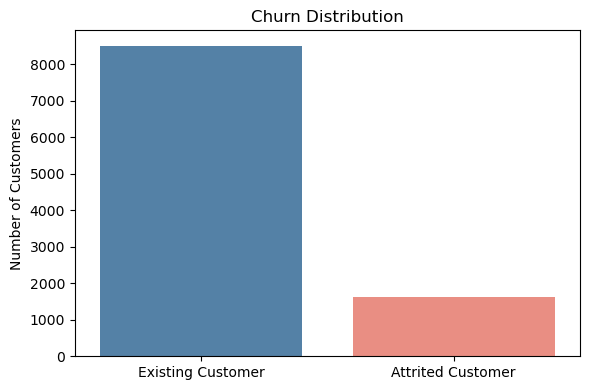

In [9]:
print(df['Attrition_Flag'].unique())
df['Churn'] =(df['Attrition_Flag'] =='Attrited Customer').astype(int)
churn_counts=df['Churn'].value_counts()
churn_pct =df['Churn'].value_counts(normalize=True)*100
print("Churn Distribution:")
print(f"Existing Customers: {churn_counts[0]}({churn_pct[0]:.1f}%)")
print(f"Churned Customers:  {churn_counts[1]}({churn_pct[1]:.1f}%)")

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition_Flag', data=df, palette=['steelblue','salmon'])
plt.title('Churn Distribution')
plt.xlabel('')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('outputs/churn_distribution.png', dpi=150)
plt.show()

### Column Types Overview

In [10]:
categorical=df.select_dtypes(include='object').columns.tolist()
numerical=df.select_dtypes(include=np.number).columns.tolist()
print(f"Categorical columns({len(categorical)}):")
for c in categorical:
    print(f"  -{c}")
print(f"Numerical columns({len(numerical)}):")
for c in numerical:
    print(f"  -{c}")

Categorical columns(6):
  -Attrition_Flag
  -Gender
  -Education_Level
  -Marital_Status
  -Income_Category
  -Card_Category
Numerical columns(16):
  -CLIENTNUM
  -Customer_Age
  -Dependent_count
  -Months_on_book
  -Total_Relationship_Count
  -Months_Inactive_12_mon
  -Contacts_Count_12_mon
  -Credit_Limit
  -Total_Revolving_Bal
  -Avg_Open_To_Buy
  -Total_Amt_Chng_Q4_Q1
  -Total_Trans_Amt
  -Total_Trans_Ct
  -Total_Ct_Chng_Q4_Q1
  -Avg_Utilization_Ratio
  -Churn


### Summary & Key Findings

- Dataset contains 10,127 customers and 21 features after I dropped irrelevant columns
- There is no missing values and no duplicate rows, so dataset is clean
- I encoded target variable (Attrition_Flag) as Churn (1 = churned, 0 = existing)
- 16% churn rate confirms class imbalance, so I will use SMOTE in modeling
- There are mix of categorical and numerical features, so I will use encoding before modeling